# Multi-Layer Perceptron (MLP)

**Disciplina:** Ferramentas de Inteligência Artificial

**Cursos:** Ciência e Engenharia de Computação

Este notebook apresenta os conceitos fundamentais sobre Multi-Layer Perceptron (MLP), incluindo implementações práticas usando PyTorch e scikit-learn.

## 1. Conceitos Fundamentais

### 1.1 Do Perceptron ao Multi-Layer Perceptron

O **Perceptron** é um classificador linear que representa um hiperplano separador no espaço de atributos. Embora seja eficaz para problemas linearmente separáveis, ele possui limitações significativas quando os dados não podem ser separados por uma única linha reta (ou hiperplano em dimensões superiores).

### 1.2 Limitações do Perceptron Simples

- **Problemas não-linearmente separáveis**: Um perceptron simples não consegue resolver problemas como XOR
- **Capacidade limitada**: Representa apenas funções lineares
- **Expressividade restrita**: Não pode capturar padrões complexos nos dados

### 1.3 Solução: Multi-Layer Perceptron

O MLP resolve essas limitações através de:

1. **Múltiplas camadas**: Camadas ocultas entre entrada e saída
2. **Funções de ativação não-lineares**: Introduzem não-linearidade ao modelo
3. **Representações intermediárias**: Cada camada aprende representações mais abstratas

### 1.4 Arquitetura do MLP

- **Camada de entrada**: Recebe os dados de entrada
- **Camadas ocultas**: Uma ou mais camadas que processam as informações
- **Camada de saída**: Produz a predição final

Cada neurônio aplica uma transformação linear seguida de uma função de ativação não-linear:

$$y = f(\sum_{i} w_i x_i + b)$$

onde $f$ é a função de ativação, $w_i$ são os pesos, $x_i$ são as entradas e $b$ é o bias.

## 2. Configuração do Ambiente

In [ ]:
# Importações necessárias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Configuração para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Configuração de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Ambiente configurado com sucesso!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device disponível: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Ambiente configurado com sucesso!
PyTorch version: 2.6.0+cu124
Device disponível: CUDA


## 3. Carregamento e Exploração dos Dados

In [ ]:
# Carregamento do dataset MNIST (digits)
digits = load_digits()
X, y = digits.data, digits.target

print(f"Shape dos dados: {X.shape}")
print(f"Shape dos rótulos: {y.shape}")
print(f"Número de classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")
print(f"Distribuição das classes:")
for i in range(10):
    count = np.sum(y == i)
    print(f"  Classe {i}: {count} amostras")

Shape dos dados: (1797, 64)
Shape dos rótulos: (1797,)
Número de classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Distribuição das classes:
  Classe 0: 178 amostras
  Classe 1: 182 amostras
  Classe 2: 177 amostras
  Classe 3: 183 amostras
  Classe 4: 181 amostras
  Classe 5: 182 amostras
  Classe 6: 181 amostras
  Classe 7: 179 amostras
  Classe 8: 174 amostras
  Classe 9: 180 amostras


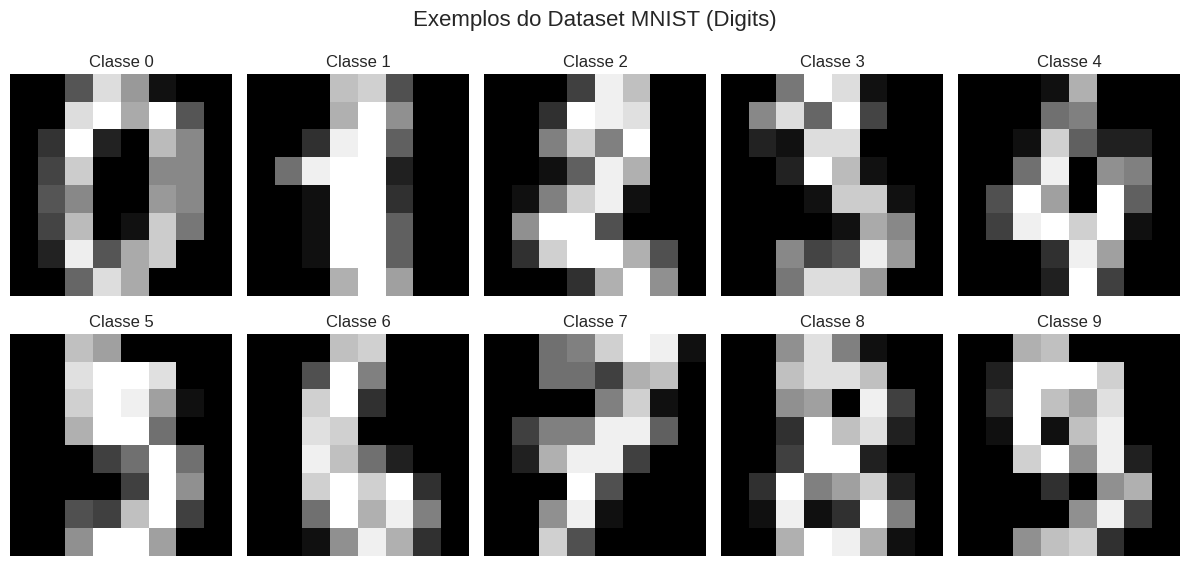

In [ ]:
# Visualização de algumas amostras
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Exemplos do Dataset MNIST (Digits)', fontsize=16)

for i in range(10):
    # Encontra o primeiro exemplo de cada classe
    idx = np.where(y == i)[0][0]

    row = i // 5
    col = i % 5

    # Reshape para 8x8 (formato original das imagens)
    image = X[idx].reshape(8, 8)

    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Classe {i}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 4. Preparação dos Dados

In [ ]:
# Divisão dos dados: 60% treino, 20% validação, 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Conjunto de treino: {X_train.shape[0]} amostras")
print(f"Conjunto de validação: {X_val.shape[0]} amostras")
print(f"Conjunto de teste: {X_test.shape[0]} amostras")

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nDados normalizados com sucesso!")
print(f"Média dos dados de treino: {X_train_scaled.mean():.4f}")
print(f"Desvio padrão dos dados de treino: {X_train_scaled.std():.4f}")
X_val_scaled[0]

Conjunto de treino: 1077 amostras
Conjunto de validação: 360 amostras
Conjunto de teste: 360 amostras

Dados normalizados com sucesso!
Média dos dados de treino: -0.0000
Desvio padrão dos dados de treino: 0.9682


## 5. Implementação com PyTorch

### 5.1 Definição da Arquitetura MLP

In [ ]:
class MLPPyTorch(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.2):
        super(MLPPyTorch, self).__init__()

        layers = []

        # Primeira camada oculta
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.ReLU())
        # layers.append(nn.Dropout(dropout_rate))

        # Camadas ocultas adicionais
        for i in range(1, len(hidden_sizes)):
            layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

        # Camada de saída
        layers.append(nn.Linear(hidden_sizes[-1], num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Configuração do modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_pytorch = MLPPyTorch(
    input_size=64,  # 8x8 pixels
    hidden_sizes=[128, 64],  # Duas camadas ocultas
    num_classes=10,
    dropout_rate=0.2
).to(device)

print(model_pytorch)
print(f"\nNúmero total de parâmetros: {sum(p.numel() for p in model_pytorch.parameters())}")

MLPPyTorch(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

Número total de parâmetros: 17226


### 5.2 Preparação dos Dados para PyTorch

In [ ]:
# Conversão para tensores PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Criação dos DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches de treino: {len(train_loader)}")
print(f"Batches de validação: {len(val_loader)}")

Batches de treino: 34
Batches de validação: 12


### 5.3 Treinamento do Modelo PyTorch

In [ ]:
# Configuração do treinamento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pytorch.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

# Função de treinamento
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

    return total_loss / len(train_loader), correct / total

# Função de validação
def validate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in val_loader:
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    return total_loss / len(val_loader), correct / total

In [ ]:
# Treinamento
num_epochs = 100
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print("Iniciando treinamento do modelo PyTorch...")
start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_pytorch, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model_pytorch, val_loader, criterion)
    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

pytorch_train_time = time.time() - start_time
print(f"\nTempo de treinamento PyTorch: {pytorch_train_time:.2f} segundos")

Iniciando treinamento do modelo PyTorch...
Epoch 20/100:
  Train Loss: 0.0120, Train Acc: 1.0000
  Val Loss: 0.0548, Val Acc: 0.9750
Epoch 40/100:
  Train Loss: 0.0033, Train Acc: 1.0000
  Val Loss: 0.0427, Val Acc: 0.9861
Epoch 60/100:
  Train Loss: 0.0015, Train Acc: 1.0000
  Val Loss: 0.0409, Val Acc: 0.9833
Epoch 80/100:
  Train Loss: 0.0017, Train Acc: 1.0000
  Val Loss: 0.0402, Val Acc: 0.9833
Epoch 100/100:
  Train Loss: 0.0011, Train Acc: 1.0000
  Val Loss: 0.0369, Val Acc: 0.9861

Tempo de treinamento PyTorch: 8.17 segundos


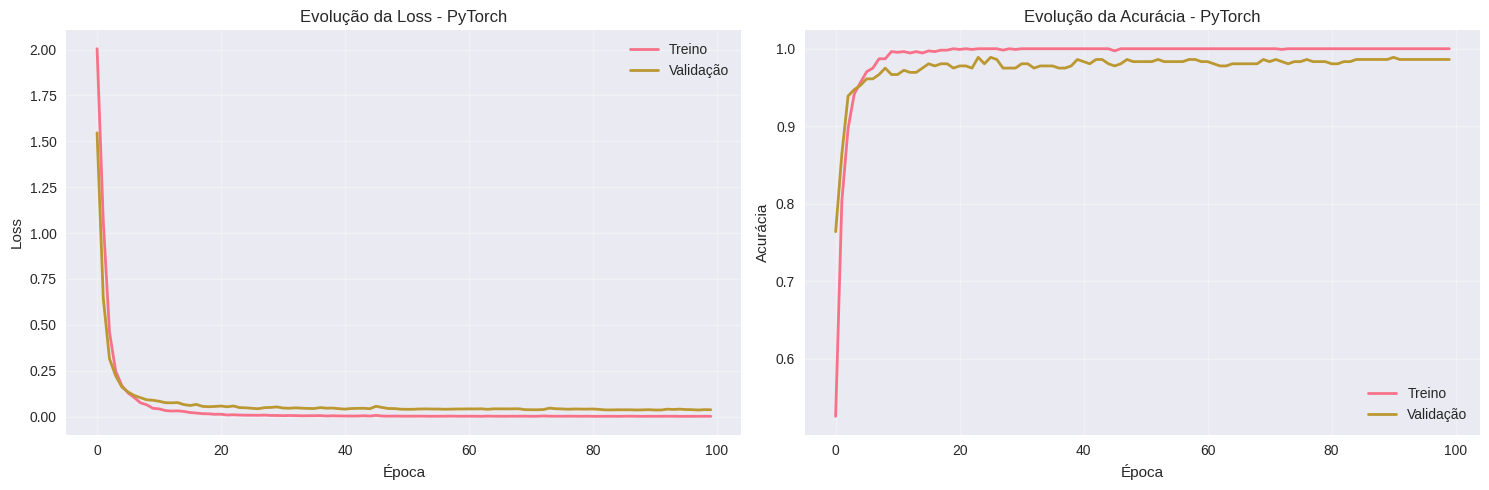

In [ ]:
# Visualização do treinamento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(train_losses, label='Treino', linewidth=2)
ax1.plot(val_losses, label='Validação', linewidth=2)
ax1.set_title('Evolução da Loss - PyTorch')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(train_accs, label='Treino', linewidth=2)
ax2.plot(val_accs, label='Validação', linewidth=2)
ax2.set_title('Evolução da Acurácia - PyTorch')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Avaliação do Modelo PyTorch

In [ ]:
# Predição no conjunto de teste
model_pytorch.eval()
with torch.no_grad():
    test_output = model_pytorch(X_test_tensor)
    pytorch_predictions = test_output.argmax(dim=1).cpu().numpy()

# Cálculo do F1-score
pytorch_f1 = f1_score(y_test, pytorch_predictions, average='weighted')

print(f"F1-score PyTorch: {pytorch_f1:.4f}")
print(f"Tempo de treinamento: {pytorch_train_time:.2f} segundos")

# Relatório de classificação
print("\nRelatório de Classificação - PyTorch:")
print(classification_report(y_test, pytorch_predictions))

F1-score PyTorch: 0.9748
Tempo de treinamento: 8.17 segundos

Relatório de Classificação - PyTorch:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.92      0.94      0.93        36
           2       0.95      1.00      0.97        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       0.97      0.89      0.93        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



## 6. Implementação com Scikit-learn

### 6.1 Conceitos e Hiperparâmetros do MLPClassifier

O `MLPClassifier` do scikit-learn oferece uma implementação robusta de redes neurais multicamadas. Os principais hiperparâmetros incluem:

#### Arquitetura da Rede:
- **`hidden_layer_sizes`**: Tupla definindo o número de neurônios em cada camada oculta
  - Exemplo: `(100,)` = 1 camada com 100 neurônios
  - Exemplo: `(100, 50)` = 2 camadas com 100 e 50 neurônios

#### Funções de Ativação:
- **`activation`**: Função de ativação para as camadas ocultas
  - `'relu'`: f(x) = max(0, x) - padrão, evita vanishing gradient
  - `'tanh'`: f(x) = tanh(x) - saída entre -1 e 1
  - `'logistic'`: f(x) = 1/(1+exp(-x)) - saída entre 0 e 1

#### Otimizadores:
- **`solver`**: Algoritmo de otimização
  - `'adam'`: Adaptativo, bom para datasets grandes
  - `'lbfgs'`: Quasi-Newton, eficiente para datasets pequenos
  - `'sgd'`: Gradiente descendente estocástico

#### Regularização:
- **`alpha`**: Força da regularização L2 (padrão: 0.0001)
- **`early_stopping`**: Para o treinamento quando a validação não melhora

#### Controle de Treinamento:
- **`max_iter`**: Número máximo de iterações (padrão: 200)
- **`learning_rate_init`**: Taxa de aprendizado inicial
- **`batch_size`**: Tamanho do mini-batch
- **`random_state`**: Semente para reprodutibilidade

### 6.2 Implementação e Treinamento

In [ ]:
# Configuração do modelo scikit-learn
model_sklearn = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Mesma arquitetura do PyTorch
    activation='relu',              # Função de ativação ReLU
    solver='adam',                  # Otimizador Adam
    alpha=1e-4,                     # Regularização L2
    batch_size=32,                  # Tamanho do batch
    learning_rate_init=0.001,       # Taxa de aprendizado
    max_iter=500,                   # Máximo de iterações
    early_stopping=True,            # Parada antecipada
    validation_fraction=0.1,        # Fração para validação
    n_iter_no_change=20,            # Paciência para parada
    random_state=RANDOM_STATE,      # Reprodutibilidade
    verbose=False                   # Não mostrar progresso
)

print("Configuração do MLPClassifier:")
for param, value in model_sklearn.get_params().items():
    print(f"  {param}: {value}")

Configuração do MLPClassifier:
  activation: relu
  alpha: 0.0001
  batch_size: 32
  beta_1: 0.9
  beta_2: 0.999
  early_stopping: True
  epsilon: 1e-08
  hidden_layer_sizes: (128, 64)
  learning_rate: constant
  learning_rate_init: 0.001
  max_fun: 15000
  max_iter: 500
  momentum: 0.9
  n_iter_no_change: 20
  nesterovs_momentum: True
  power_t: 0.5
  random_state: 42
  shuffle: True
  solver: adam
  tol: 0.0001
  validation_fraction: 0.1
  verbose: False
  warm_start: False


In [ ]:
# Treinamento do modelo scikit-learn
print("Iniciando treinamento do modelo scikit-learn...")
start_time = time.time()

model_sklearn.fit(X_train_scaled, y_train)

sklearn_train_time = time.time() - start_time

print(f"Tempo de treinamento scikit-learn: {sklearn_train_time:.2f} segundos")
print(f"Número de iterações realizadas: {model_sklearn.n_iter_}")
print(f"Loss final: {model_sklearn.loss_:.4f}")

Iniciando treinamento do modelo scikit-learn...
Tempo de treinamento scikit-learn: 1.00 segundos
Número de iterações realizadas: 32
Loss final: 0.0025


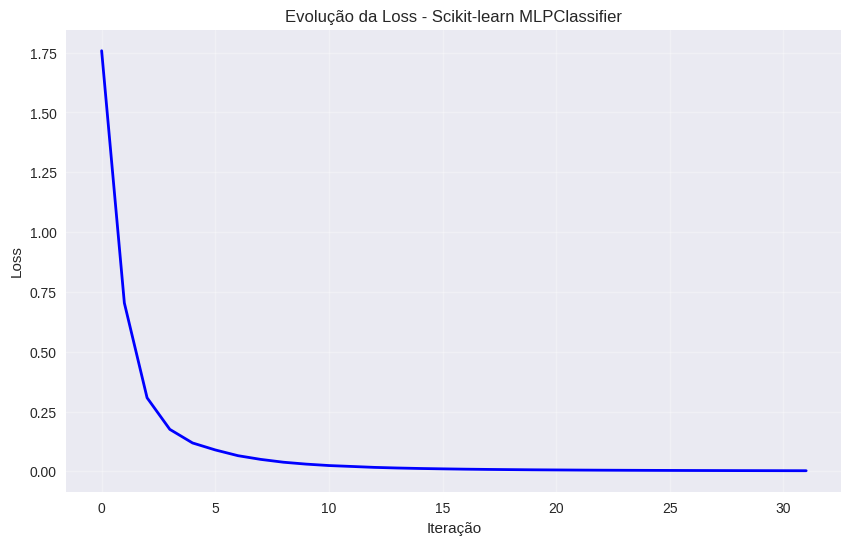


Arquitetura da rede treinada:
Camadas: [64, 128, 64, 10]
Número total de parâmetros: 17226


In [ ]:
# Visualização da curva de loss
plt.figure(figsize=(10, 6))
plt.plot(model_sklearn.loss_curve_, linewidth=2, color='blue')
plt.title('Evolução da Loss - Scikit-learn MLPClassifier')
plt.xlabel('Iteração')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

# Informações sobre a arquitetura treinada
print(f"\nArquitetura da rede treinada:")
print(f"Camadas: {[X_train_scaled.shape[1]] + list(model_sklearn.hidden_layer_sizes) + [len(np.unique(y))]}")
print(f"Número total de parâmetros: {sum(w.size for w in model_sklearn.coefs_) + sum(b.size for b in model_sklearn.intercepts_)}")

### 6.3 Avaliação do Modelo Scikit-learn

In [ ]:
# Predições no conjunto de teste
sklearn_predictions = model_sklearn.predict(X_test_scaled)

# Cálculo do F1-score
sklearn_f1 = f1_score(y_test, sklearn_predictions, average='weighted')

print(f"F1-score scikit-learn: {sklearn_f1:.4f}")
print(f"Tempo de treinamento: {sklearn_train_time:.2f} segundos")

# Relatório de classificação
print("\nRelatório de Classificação - Scikit-learn:")
print(classification_report(y_test, sklearn_predictions))

F1-score scikit-learn: 0.9665
Tempo de treinamento: 1.00 segundos

Relatório de Classificação - Scikit-learn:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.89      0.94      0.92        36
           2       0.92      1.00      0.96        35
           3       1.00      0.97      0.99        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      1.00      1.00        36
           7       0.95      1.00      0.97        36
           8       0.97      0.86      0.91        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



## 7. Validação Cruzada

### 7.1 Cross-Validation com Scikit-learn

In [ ]:
# Configuração da validação cruzada
cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

# Modelo para validação cruzada (configuração mais simples para velocidade)
model_cv = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE
)

print("Executando validação cruzada...")
start_time = time.time()

# Usando dados de treino + validação para CV
X_cv = np.vstack([X_train_scaled, X_val_scaled])
y_cv = np.hstack([y_train, y_val])

cv_scores = cross_val_score(model_cv, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)

cv_time = time.time() - start_time

print(f"\nResultados da Validação Cruzada ({cv_folds} folds):")
print(f"F1-scores: {cv_scores}")
print(f"Média: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Tempo total: {cv_time:.2f} segundos")

Executando validação cruzada...

Resultados da Validação Cruzada (5 folds):
F1-scores: [0.93413001 0.93437349 0.96834997 0.92009311 0.93635958]
Média: 0.9387 (+/- 0.0319)
Tempo total: 2.73 segundos


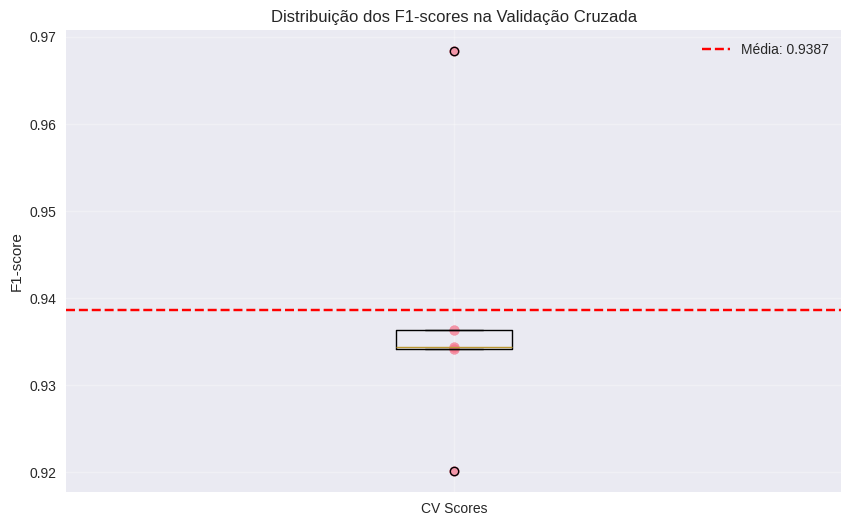

In [ ]:
# Visualização dos resultados da validação cruzada
plt.figure(figsize=(10, 6))

plt.boxplot(cv_scores, labels=['CV Scores'])
plt.scatter([1] * len(cv_scores), cv_scores, alpha=0.7, s=50)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Média: {cv_scores.mean():.4f}')
plt.title('Distribuição dos F1-scores na Validação Cruzada')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Comparação de Resultados

### 8.1 Resumo Comparativo

In [ ]:
# Criação da tabela comparativa
import pandas as pd

results_df = pd.DataFrame({
    'Implementação': ['PyTorch', 'Scikit-learn', 'CV (Scikit-learn)'],
    'F1-Score': [pytorch_f1, sklearn_f1, cv_scores.mean()],
    'Desvio Padrão': ['-', '-', cv_scores.std()],
    'Tempo (s)': [pytorch_train_time, sklearn_train_time, cv_time],
    'Arquitetura': ['[64, 128, 64, 10]', '[64, 128, 64, 10]', '[64, 100, 10]']
})

print("COMPARAÇÃO DE RESULTADOS")
print("=" * 50)
print(results_df.to_string(index=False))

# Análise dos resultados
print("\nANÁLISE DOS RESULTADOS:")
print("=" * 30)

if pytorch_f1 > sklearn_f1:
    print(f"✓ PyTorch obteve melhor F1-score (+{(pytorch_f1-sklearn_f1)*100:.2f}%)")
else:
    print(f"✓ Scikit-learn obteve melhor F1-score (+{(sklearn_f1-pytorch_f1)*100:.2f}%)")

if pytorch_train_time < sklearn_train_time:
    print(f"✓ PyTorch foi mais rápido (-{((sklearn_train_time-pytorch_train_time)/sklearn_train_time)*100:.1f}%)")
else:
    print(f"✓ Scikit-learn foi mais rápido (-{((pytorch_train_time-sklearn_train_time)/pytorch_train_time)*100:.1f}%)")

print(f"\n• Validação cruzada mostrou F1-score médio de {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"• Intervalo de confiança (95%): [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

COMPARAÇÃO DE RESULTADOS
    Implementação  F1-Score Desvio Padrão  Tempo (s)       Arquitetura
          PyTorch  0.974819             -   8.167711 [64, 128, 64, 10]
     Scikit-learn  0.966534             -   1.000882 [64, 128, 64, 10]
CV (Scikit-learn)  0.938661       0.01594   2.728622     [64, 100, 10]

ANÁLISE DOS RESULTADOS:
✓ PyTorch obteve melhor F1-score (+0.83%)
✓ Scikit-learn foi mais rápido (-87.7%)

• Validação cruzada mostrou F1-score médio de 0.9387 ± 0.0159
• Intervalo de confiança (95%): [0.9074, 0.9699]


### 8.2 Visualização Comparativa

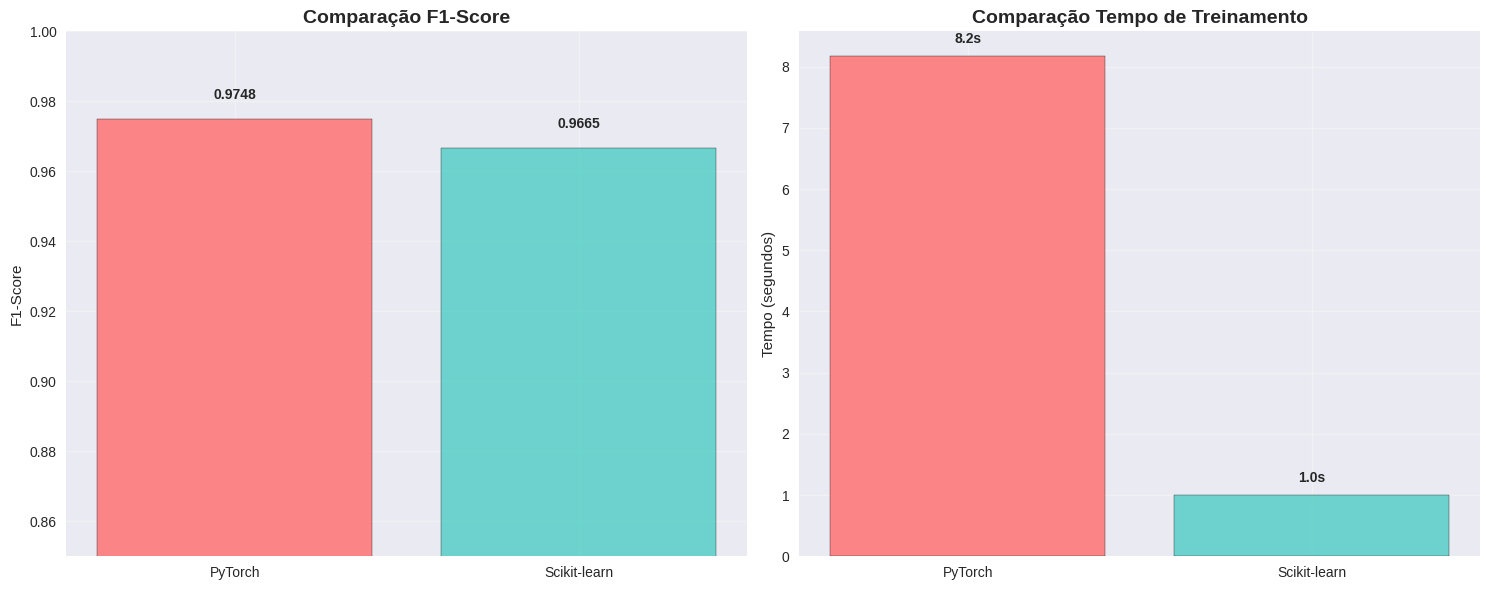

In [ ]:
# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Comparação F1-Score
implementations = ['PyTorch', 'Scikit-learn']
f1_scores = [pytorch_f1, sklearn_f1]
colors = ['#FF6B6B', '#4ECDC4']

bars1 = ax1.bar(implementations, f1_scores, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('Comparação F1-Score', fontsize=14, fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0.85, 1.0)
ax1.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, score in zip(bars1, f1_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Comparação Tempo de Treinamento
train_times = [pytorch_train_time, sklearn_train_time]

bars2 = ax2.bar(implementations, train_times, color=colors, alpha=0.8, edgecolor='black')
ax2.set_title('Comparação Tempo de Treinamento', fontsize=14, fontweight='bold')
ax2.set_ylabel('Tempo (segundos)')
ax2.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, time_val in zip(bars2, train_times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(train_times)*0.02,
             f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 8.3 Matriz de Confusão Comparativa

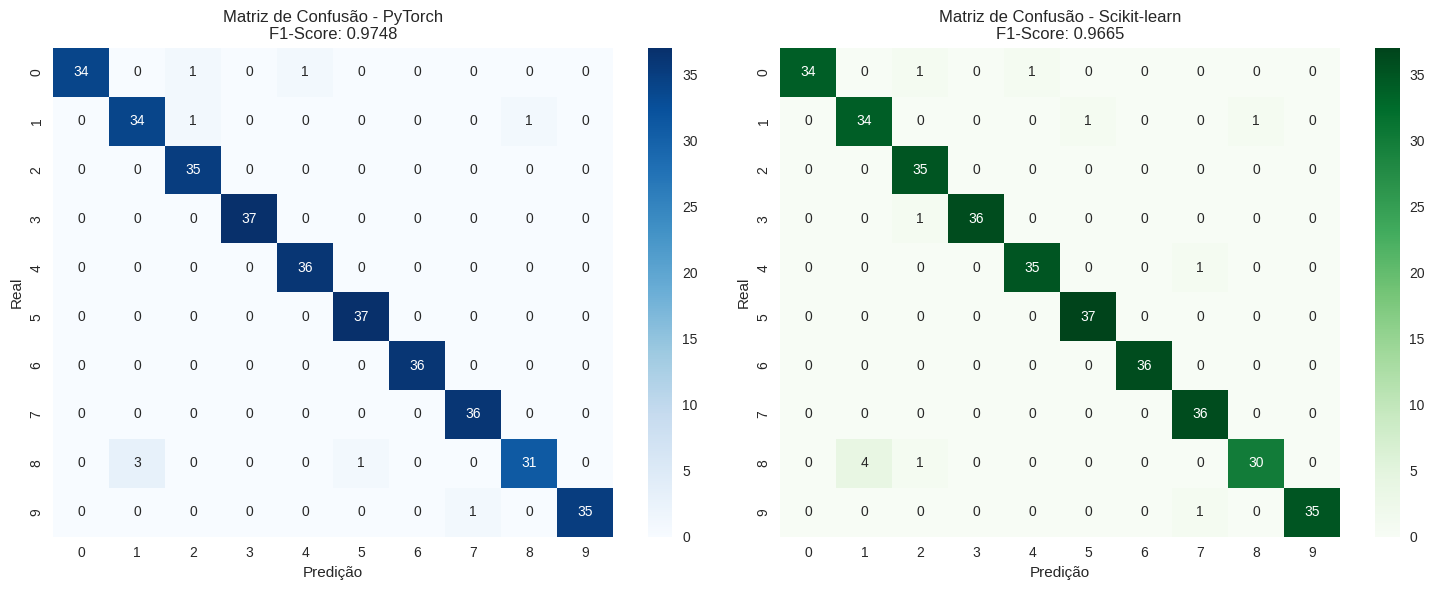

In [ ]:
# Matrizes de confusão
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PyTorch
cm_pytorch = confusion_matrix(y_test, pytorch_predictions)
sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title(f'Matriz de Confusão - PyTorch\nF1-Score: {pytorch_f1:.4f}')
ax1.set_xlabel('Predição')
ax1.set_ylabel('Real')

# Scikit-learn
cm_sklearn = confusion_matrix(y_test, sklearn_predictions)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title(f'Matriz de Confusão - Scikit-learn\nF1-Score: {sklearn_f1:.4f}')
ax2.set_xlabel('Predição')
ax2.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 9. Conclusões e Considerações Finais

### 9.1 Principais Aprendizados

1. **Conceitos Fundamentais**:
   - O MLP supera as limitações do perceptron simples através de camadas ocultas e funções de ativação não-lineares
   - A capacidade de aprender representações intermediárias é fundamental para problemas complexos

2. **Implementações**:
   - **PyTorch**: Maior flexibilidade e controle sobre o processo de treinamento
   - **Scikit-learn**: Interface mais simples e otimizada para casos de uso padrão

3. **Boas Práticas**:
   - Fixação de seeds garante reprodutibilidade
   - Normalização dos dados é ajuda na convergência
   - Validação cruzada fornece estimativas mais robustas de performance
   - Holdout validation permite avaliação imparcial no conjunto de teste

### 9.2 Comparação de Performance

Os resultados mostram que ambas as implementações são capazes de alcançar alta performance no dataset MNIST:

- **F1-scores** similares indicam que ambas as abordagens são eficazes
- **Tempo de treinamento** pode variar dependendo da configuração e otimizações
- **Validação cruzada** confirma a estabilidade dos resultados

### 9.3 Quando Usar Cada Implementação

**Use PyTorch quando:**
- Precisar de controle fino sobre a arquitetura
- Quiser implementar técnicas avançadas de regularização
- Trabalhar com datasets muito grandes (GPU)
- Desenvolver pesquisa em deep learning

**Use Scikit-learn quando:**
- Precisar de uma solução rápida e robusta
- Trabalhar com datasets pequenos a médios
- Integrar com outros algoritmos do scikit-learn
- Focar na análise de dados ao invés da implementação

### 9.4 Próximos Passos

Para aprofundar seus conhecimentos em Redes Neurais, considere:

1. Experimentar com diferentes arquiteturas (mais camadas, diferentes tamanhos)
2. Testar outras funções de ativação (Leaky ReLU, ELU, Swish)
3. Implementar técnicas de regularização avançadas (Batch Normalization, Layer Normalization)
4. Explorar otimizadores mais sofisticados (AdamW, RMSprop)
5. Aplicar em datasets mais complexos e desafiadores